# 06 - Segment Profiling and Insights

Profiling the 5 customer segments identified and translating the findings into actionable business recommendations
for the product and growth teams.

Central question: Who are our customers post-pivot, and which ones can we save?

In [16]:
# Set up
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from settings import PATHS, apply_pandas_settings, apply_plot_settings

apply_pandas_settings()
apply_plot_settings()

In [17]:
segments = pd.read_csv(PATHS['segments'])
segments.head()

,customer_id,frequency,monetary,recency,pre_pivot_frequency,pivot_ratio,product_diversity,loan_taken,loan_defaulted,clusters
0,CUS00001,11,351800.00,6,10,1.00,4,0,0,4
1,CUS00002,1,90250.00,27,10,0.09,1,1,0,3
2,CUS00003,0,0.00,184,6,0.00,0,1,0,3
3,CUS00004,15,1122650.00,13,9,1.50,5,0,0,0
4,CUS00005,0,0.00,184,3,0.00,0,1,1,1


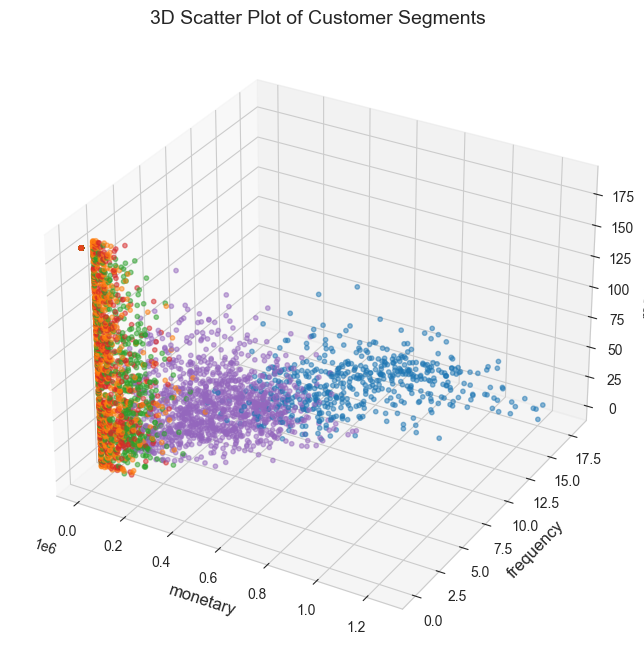

In [18]:
# Visualizing the segments by RFM

cluster_colors = {
    0: "#1f77b4",   # Blue
    1: "#ff7f0e",   # Orange
    2: "#2ca02c",   # Green
    3: "#d62728",   # Red
    4: "#9467bd",   # Purple
}

colors = segments["clusters"].map(cluster_colors)

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    segments["monetary"],   
    segments["frequency"],    
    segments["recency"],     
    c=colors,
    marker="o",
    alpha=0.5,
    s=10
)

ax.set_xlabel("monetary")
ax.set_ylabel("frequency")
ax.set_zlabel("recency")
ax.set_title("3D Scatter Plot of Customer Segments")

plt.show()

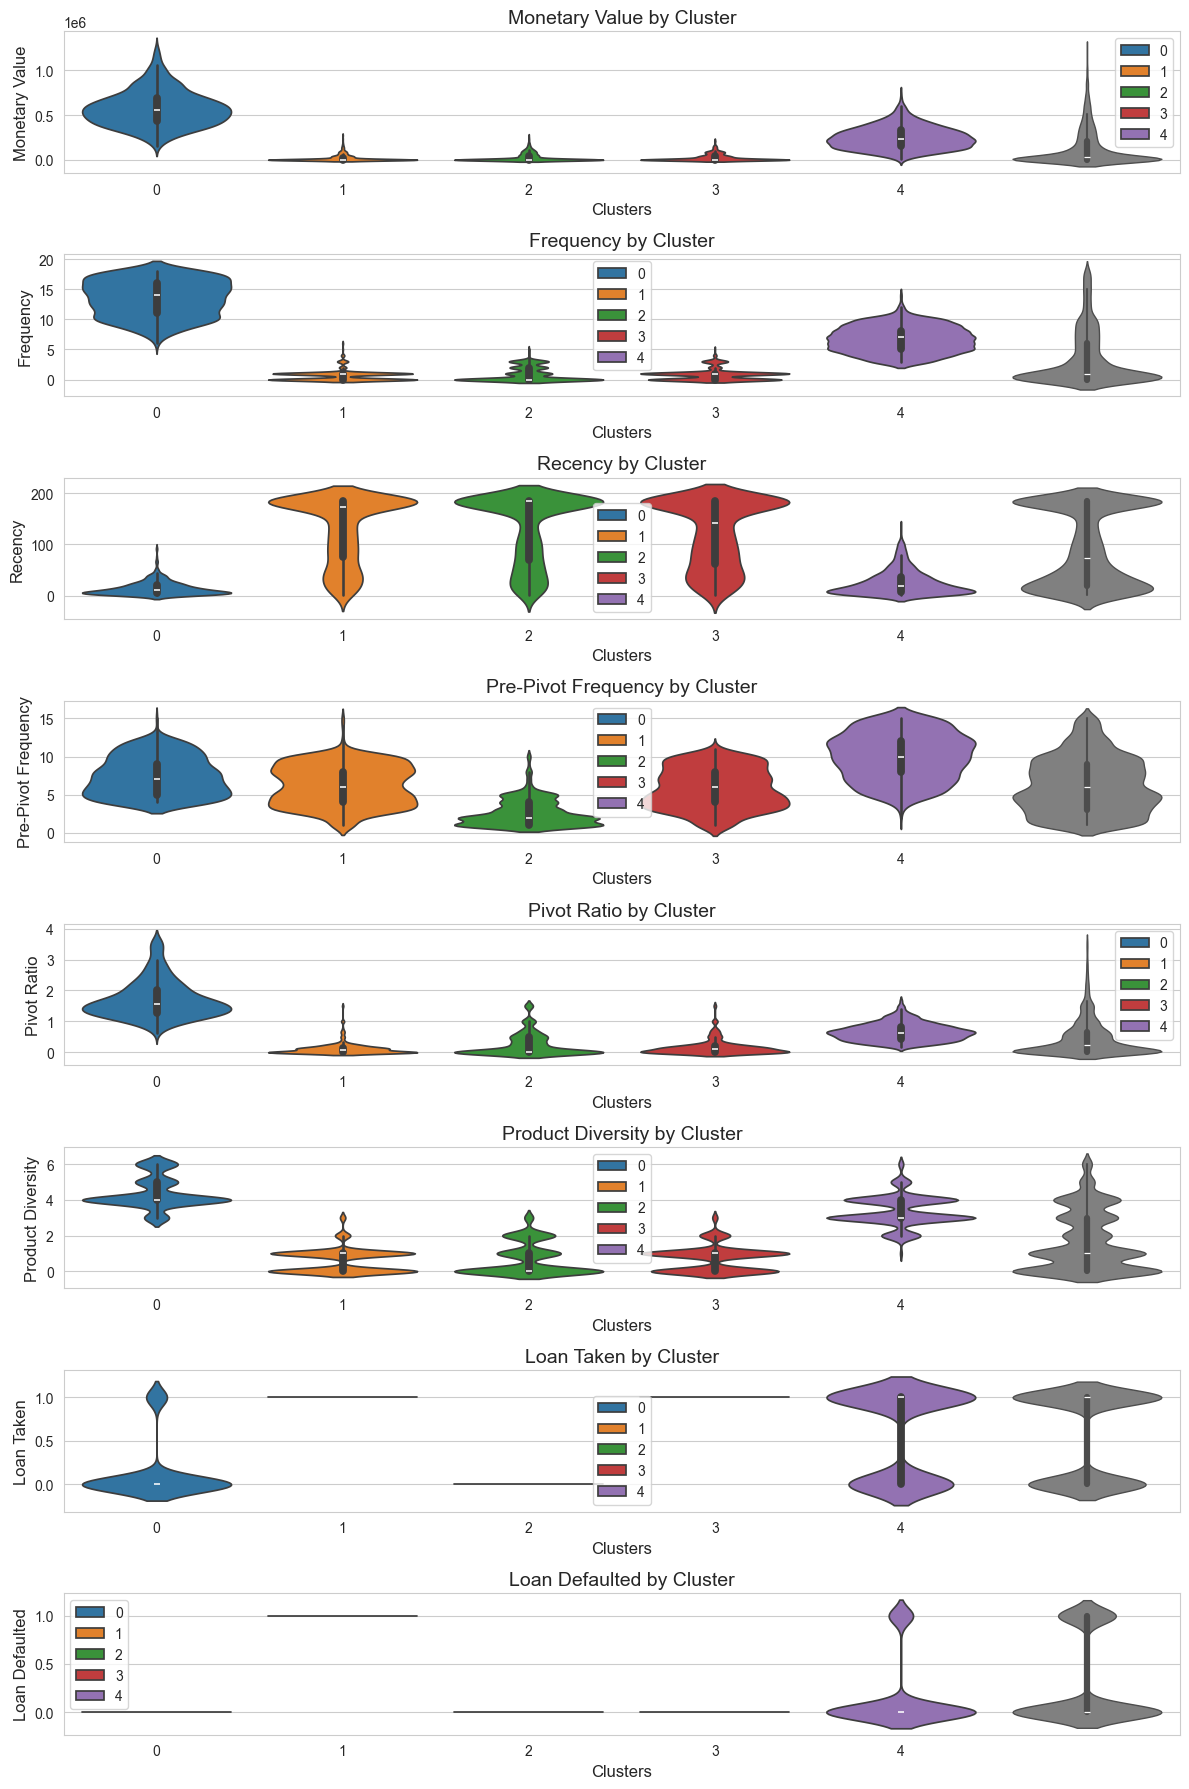

In [19]:
# Cluster Analysis using the Violin Plots

plt.figure(figsize = (12, 18))

plt.subplot(8,1,1)
sns.violinplot(x = segments['clusters'], y = segments['monetary'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['monetary'], color = 'gray', linewidth = 1.0)
plt.title('Monetary Value by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Monetary Value')

plt.subplot(8,1,2)
sns.violinplot(x = segments['clusters'], y = segments['frequency'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['frequency'], color = 'gray', linewidth = 1.0)
plt.title('Frequency by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Frequency')

plt.subplot(8,1,3)
sns.violinplot(x = segments['clusters'], y = segments['recency'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['recency'], color = 'gray', linewidth = 1.0)
plt.title('Recency by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Recency')

plt.subplot(8,1,4)
sns.violinplot(x = segments['clusters'], y = segments['pre_pivot_frequency'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['pre_pivot_frequency'], color = 'gray', linewidth = 1.0)
plt.title('Pre-Pivot Frequency by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Pre-Pivot Frequency')

plt.subplot(8,1,5)
sns.violinplot(x = segments['clusters'], y = segments['pivot_ratio'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['pivot_ratio'], color = 'gray', linewidth = 1.0)
plt.title('Pivot Ratio by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Pivot Ratio')

plt.subplot(8,1,6)
sns.violinplot(x = segments['clusters'], y = segments['product_diversity'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['product_diversity'], color = 'gray', linewidth = 1.0)
plt.title('Product Diversity by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Product Diversity')

plt.subplot(8,1,7)
sns.violinplot(x = segments['clusters'], y = segments['loan_taken'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['loan_taken'], color = 'gray', linewidth = 1.0)
plt.title('Loan Taken by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Loan Taken')

plt.subplot(8,1,8)
sns.violinplot(x = segments['clusters'], y = segments['loan_defaulted'], palette = cluster_colors, hue = segments['clusters'])
sns.violinplot(y = segments['loan_defaulted'], color = 'gray', linewidth = 1.0)
plt.title('Loan Defaulted by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Loan Defaulted')

plt.tight_layout()
plt.show()

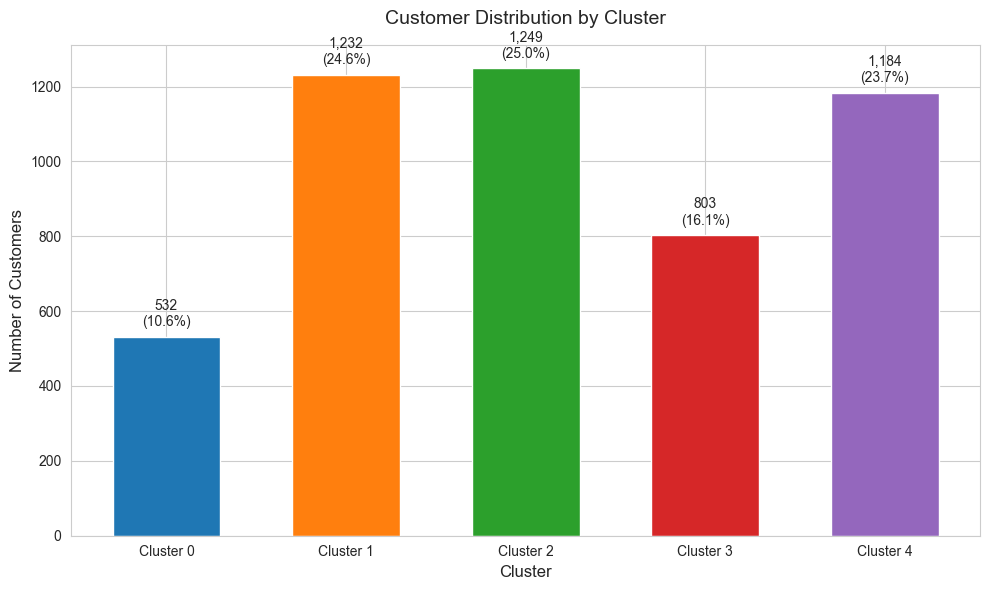

In [20]:
# Cluster size distribution

cluster_colors = {
    0: "#1f77b4",   # Blue
    1: "#ff7f0e",   # Orange
    2: "#2ca02c",   # Green
    3: "#d62728",   # Red
    4: "#9467bd",   # Purple
}

cluster_counts = segments["clusters"].value_counts().sort_index()

fig, ax = plt.subplots()

bars = ax.bar(
    [f"Cluster {i}" for i in cluster_counts.index],
    cluster_counts.values,
    color=[cluster_colors[i] for i in cluster_counts.index],
    edgecolor="white",
    width=0.6
)

ax.set_title("Customer Distribution by Cluster", pad=15)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

total = len(segments)
for bar, val in zip(bars, cluster_counts.values):
    pct = val / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()

## Segment Profiles and Business Recommendations

### Cluster 0 - Loyal Customers
**Action: Reward**

**Who they are:**
532 customers (10.6%) who never came for loans — they came for the
transactional product and stayed. They are the most active, highest
spending, most recently transacting customers on the platform.

**Evidence:**
- Highest Monetary Value
- Highest Frequency
- Lowest Recency (recently active)
- High Pivot Ratio
- Highest Product Diversity
- Very low loan dependency
- Almost no defaults

**What the data tells us:**
These customers were never loan-dependent. They came for transfers,
savings, bill payments, and airtime — and they stayed. The pivot
did not hurt them — it may have actually improved their experience
by removing the noise of a loan product they never needed.

**Business recommendation - Reward:**
- Introduce a loyalty programme — cashback on transfers, free bill
  payment charges, airtime bonuses
- Give them early access to new features — they are the most likely
  to adopt and provide useful feedback
- Do not bombard them with re-engagement campaigns — they are
  already engaged. Over-communication risks annoying your best customers
- Track them monthly — any drop in this segment is an early warning signal

### Cluster 1 - Loan-Dependent Churners
**Action: Reactivate if possible**

**Who they are:**
1,232 customers (24.6%) who came exclusively for loans, defaulted
on every single one, and essentially disappeared post-pivot.
100% loan uptake, 100% default rate, near-zero post-pivot activity.

**Evidence:**
- Very low Monetary Value
- Very low Frequency
- Extremely High Recency
- Almost zero Pivot Ratio
- Minimal Product Diversity
- Loan Taken = 1
- Loan Defaulted = 1

**What the data tells us:**
These customers represent the direct cost of the loan campaign
strategy. They came for credit, took what they could, defaulted,
and left. They are the primary reason the pivot was necessary.
Reactivating them is a low-probability exercise — they have no
demonstrated interest in transactional products and left on bad
terms financially.

**Business recommendation — Reactivate if possible:**
- Do not invest heavily in re-engagement — the ROI is low
- If attempting reactivation, lead with airtime or bill payment
  — low-friction, low-commitment entry points that do not require
  financial trust
- Do not offer any credit product to this segment under any
  circumstances — they have demonstrated they will not repay
- A small subset may respond to a fresh start campaign — simple
  messaging that the platform has evolved beyond loans
- Deprioritise this segment in marketing spend relative to
  At-Risk and Adapted customers

### Cluster 2 - Ghost Customers
**Action: Deprioritize**

**Who they are:**
1,249 customers (25.0%) who never took a loan and were barely
active even before the pivot. They signed up — possibly out of
curiosity or through the agent network — but never genuinely
engaged with any product in either period.

**Evidence:**
- Very low Monetary
- Very low Frequency
- High Recency
- Minimal Product Diversity
- Almost zero Pivot Ratio
- Loan Taken = 0
- Loan Defaulted = 0

**What the data tells us:**
These customers were never truly acquired — they exist in the
database but never formed a meaningful relationship with the
platform. They did not leave because of the pivot — they were
never really present. Their low pre-pivot frequency suggests
the onboarding process captured their details but failed to
convert them into active users.

**Business recommendation - Deprioritize:**
- Do not invest in re-engagement campaigns for this segment —
  they show no signal of intent to engage
- Investigate the onboarding journey for this segment — what
  acquisition channel brought them in and why did they never
  activate?
- Consider a single low-cost reactivation attempt — one push
  notification or SMS — then move on if there is no response
- Focus resources on Adapted and At-Risk segments where the
  probability of successful retention is significantly higher
- In the long term, use this segment to improve acquisition
  quality — fewer ghost accounts means better unit economics

### Cluster 3 — At-Risk Customers
**Action: Retain**

**Who they are:**
803 customers (16.1%) who took loans and repaid every single one —
0% default rate. They demonstrated financial discipline and had a
positive completed loan experience. Yet post-pivot their engagement
collapsed.

**Evidence:**
- Low Monetary
- Low Frequency
- High Recency
- Low Product Diversity
- Loan Taken = 1
- Default rate: 0% — every customer repaid

**What the data tells us:**
This is the most frustrating segment from a business perspective.
These customers proved they are creditworthy — they repaid their
loans — but the company can no longer serve their primary need.
They have not churned completely but they are barely present.
They are the most recoverable of the disengaged segments because
they left on good terms — no default, no bad experience.

**Business recommendation — Retain:**
- Re-engage with a direct message acknowledging their loyalty as
  responsible borrowers — personalised outreach works better than
  generic campaigns for this group
- Offer them a premium savings product — customers who repaid loans
  have demonstrated financial discipline and are good candidates
  for savings products with better interest rates
- If the company ever reintroduces any form of credit — buy now pay
  later, salary advance — this segment should be first in line
- Time is critical — Intervention should happen immediately

### Cluster 4 — Adapted Customers
**Action: Nurture**

**Who they are:**
1,184 customers (23.7%) who were highly active pre-pivot (average
10 transactions) and maintained reasonable post-pivot engagement
(average 6 transactions). They had mixed loan history but most
importantly they found reasons to stay after loans disappeared.

**Evidence:**
- High Monetary Value
- Moderate-High Frequency
- Low Recency (active)
- Good Product Diversity
- Strong Pre-Pivot Frequency
- Many took loans
- Few actually defaulted
- Moderate Pivot Ratio

**What the data tells us:**
These customers had a broad enough relationship with the platform
that when loans disappeared, they stayed. Their pre-pivot frequency
was the highest of any segment — they were power users before the
pivot. The fact that they maintained post-pivot activity
despite losing the loan product speaks to genuine platform loyalty.

**Business recommendation — Nurture:**
- Push personalised product recommendations based on their existing
  transaction type usage — encourage them toward higher diversity
- Offer savings incentives — interest rate bonuses or savings
  milestones — to deepen their financial relationship
- Target them with Transfer fee waivers — transfers are the most
  resilient post-pivot product and this segment is well placed to
  increase transfer activity
- Monitor their pivot ratio monthly — any sustained decline signals
  they are moving toward the At-Risk segment

In [21]:
# Save final labelled segments
segments.to_csv(PATHS["segments"], index=False)